## 1. Chargement et Préparation des Données

1.1 Import des librairies

Nous commençons par importer les librairies nécessaires pour l'analyse de données, la modélisation et la visualisation.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
import warnings

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

pio.renderers.default = "notebook_connected"

DATA_PATH = "data/export.csv"
COL_PDL = "pdl_id"
COL_DT  = "datetime"
COL_PWR = "p_kw"

1.2 Lecture des données

Les données de consommation sont stockées dans un fichier CSV. Nous les chargeons dans un DataFrame pandas. Les colonnes sont renommées pour plus de clarté :

id -> pdl_id (identifiant unique du point de livraison)

horodate -> datetime (timestamp de la mesure)

valeur -> p_kw (puissance en kW)

La colonne datetime est convertie au format datetime de pandas, en s'assurant que le fuseau horaire est correctement géré (ici, Europe/Paris). Cela est crucial pour les étapes suivantes où nous extrairons des informations temporelles (jour, heure, saison).

In [8]:
raw = pd.read_csv(DATA_PATH, sep=",")
raw = raw.rename(columns={"id": COL_PDL, "horodate": COL_DT, "valeur": COL_PWR})

# parsing datetime
raw[COL_DT] = pd.to_datetime(raw[COL_DT], utc=True, errors="coerce")

# option: forcer timezone Europe/Paris (recommandé pour "jour" et "hh_index")
# si raw[COL_DT] est tz-aware: tz_convert marche
# si tz-naive: tz_localize
if raw[COL_DT].dt.tz is None:
    raw[COL_DT] = raw[COL_DT].dt.tz_localize("Europe/Paris")
else:
    raw[COL_DT] = raw[COL_DT].dt.tz_convert("Europe/Paris")

df = raw.dropna(subset=[COL_PDL, COL_DT, COL_PWR]).copy()

df[COL_PWR] = pd.to_numeric(df[COL_PWR], errors="coerce")
df = df.dropna(subset=[COL_PWR])

df.head()

,pdl_id,datetime,p_kw
0,476866365062,2023-11-01 00:00:00+01:00,1328.1
1,476866365062,2023-11-01 00:30:00+01:00,240.7
2,476866365062,2023-11-01 01:00:00+01:00,245.7
3,476866365062,2023-11-01 01:30:00+01:00,324.5
4,476866365062,2023-11-01 02:00:00+01:00,238.0


## 1.3 Exploration initiale
Un premier aperçu des données pour vérifier le chargement, le nombre de clients et les types de données.

In [9]:
print("n_rows:", len(df))
print("n_clients:", df[COL_PDL].nunique())
print(df.dtypes)

n_rows: 8736000
n_clients: 500
pdl_id                             int64
datetime    datetime64[ns, Europe/Paris]
p_kw                             float64
dtype: object


## 2. Feature Engineering
C'est l'étape la plus importante. Nous allons créer un ensemble de variables (features) qui décrivent le comportement de consommation de chaque client sur l'ensemble de la période. L'objectif est de transformer les séries temporelles de consommation en un tableau où chaque ligne représente un client et chaque colonne une caractéristique de sa consommation.

2.1 Variables temporelles de base

Nous extrayons des informations de la colonne datetime pour faciliter les agrégations par la suite.

In [10]:
df["date"] = df[COL_DT].dt.date
df["dow"] = df[COL_DT].dt.dayofweek # day of week
df["is_weekend"] = df["dow"] >= 5
df["hh_index"] = ((df[COL_DT].dt.hour * 60) + df[COL_DT].dt.minute) // 30  # index de la demi-heure, de 0 à 47

2.2 Agrégation journalière

Nous agrégeons les données de consommation par jour pour chaque client. Cela nous donne une vue macroscopique de la consommation et réduit la dimensionnalité des données.

Nous calculons :

daily_kwh: La consommation totale journalière en kWh (en supposant des pas de 30 minutes).

daily_mean_kw: La puissance moyenne journalière.

daily_max_kw: La puissance maximale atteinte dans la journée (pic de consommation).

n_steps: Le nombre de mesures dans la journée (utile pour détecter les jours avec des données manquantes).

In [11]:
daily = (df
    .assign(energy_kwh_step=df[COL_PWR] * 0.5)
    .groupby([COL_PDL, "date"], as_index=False)
    .agg(
        daily_kwh=("energy_kwh_step", "sum"),
        daily_mean_kw=(COL_PWR, "mean"),
        daily_max_kw=(COL_PWR, "max"),
        n_steps=(COL_PWR, "size"),
    )
)

daily.head()

,pdl_id,date,daily_kwh,daily_mean_kw,daily_max_kw,n_steps
0,1704875583,2023-11-01,13571.55,565.481250,3291.2,48
1,1704875583,2023-11-02,15846.95,660.289583,3381.8,48
2,1704875583,2023-11-03,14021.70,584.237500,3447.7,48
3,1704875583,2023-11-04,16563.30,690.137500,3630.5,48
4,1704875583,2023-11-05,14427.50,601.145833,3849.8,48


2.3 Détection des jours d'activité

Pour différencier une résidence principale (habitée presque tous les jours) d'une résidence secondaire (inhabitée pendant de longues périodes), il est essentiel d'identifier les jours où il y a une consommation "significative".

Nous définissons un jour comme "actif" si sa consommation daily_kwh est supérieure à un seuil. Pour éviter de fixer un seuil arbitraire et absolu (qui ne serait pas adapté à tous les clients, petits et gros consommateurs), nous calculons un seuil dynamique par client.

Le seuil th_pdl pour chaque client est défini comme le quantile 20% (Q20) de ses consommations journalières strictement positives. Cela signifie que nous considérons un jour comme actif s'il fait partie des 80% de jours les plus consommateurs (en excluant les jours à consommation nulle).

La variable is_active_day sera notre indicateur clé pour les features suivantes.

In [12]:
# seuil par client sur les jours > 0
def q20_positive(s: pd.Series):
    s = s[s > 0]
    if len(s) == 0:
        return np.nan
    return s.quantile(0.2)

daily["th_pdl"] = (daily.groupby(COL_PDL)["daily_kwh"]
                   .transform(q20_positive))

# fallback si un client n'a pas de jours >0 : on le marque jamais actif
daily["is_active_day"] = (daily["daily_kwh"] >= daily["th_pdl"]).fillna(False)

daily.head()

,pdl_id,date,daily_kwh,daily_mean_kw,daily_max_kw,n_steps,th_pdl,is_active_day
0,1704875583,2023-11-01,13571.55,565.481250,3291.2,48,5881.95,True
1,1704875583,2023-11-02,15846.95,660.289583,3381.8,48,5881.95,True
2,1704875583,2023-11-03,14021.70,584.237500,3447.7,48,5881.95,True
3,1704875583,2023-11-04,16563.30,690.137500,3630.5,48,5881.95,True
4,1704875583,2023-11-05,14427.50,601.145833,3849.8,48,5881.95,True


2.4 Features agrégées au niveau 

Maintenant que nous avons les données journalières et la notion de jour actif, nous pouvons construire le jeu de données final pour le clustering. Chaque ligne correspondra à un client (pdl_id), et les colonnes seront les features décrivant sa consommation sur toute la période.

2.4.1 Features de saisonnalité

Les résidences secondaires peuvent présenter une forte saisonnalité (par exemple, utilisation uniquement en été). Nous créons des features pour capturer ce comportement.

On divise l'année en 3 saisons : hiver, été, et mi-saison.
On calcule la consommation journalière moyenne pour chaque saison.

On normalise ces moyennes par la consommation journalière moyenne globale du client. On obtient ainsi des ratios (r_winter, r_summer, r_mid) qui indiquent si un client sur-consomme ou sous-consomme pendant une saison donnée par rapport à sa propre moyenne.

Par exemple, un r_summer élevé pourrait indiquer une résidence secondaire estivale.

In [13]:
daily2 = daily.copy()
daily2["date_ts"] = pd.to_datetime(daily2["date"])
daily2["month"] = daily2["date_ts"].dt.month

def season_from_month(m):
    # à adapter si vous avez une définition métier différente
    if m in (12, 1, 2):
        return "winter"
    if m in (6, 7, 8):
        return "summer"
    return "mid"

daily2["season"] = daily2["month"].map(season_from_month)

season_stats = (daily2
    .groupby([COL_PDL, "season"], as_index=False)
    .agg(mean_daily_kwh=("daily_kwh", "mean"))
    .pivot(index=COL_PDL, columns="season", values="mean_daily_kwh")
    .reset_index()
)

# colonnes manquantes -> 0 (si un client n'a pas de points dans une saison)
for c in ["winter", "summer", "mid"]:
    if c not in season_stats.columns:
        season_stats[c] = 0.0

global_mean = (daily2.groupby(COL_PDL, as_index=False)
               .agg(mean_daily_kwh_global=("daily_kwh", "mean")))

season_stats = season_stats.merge(global_mean, on=COL_PDL, how="left", validate="one_to_one")

eps = 1e-9
season_stats["r_global"] = 1.0  # par définition (référence)
season_stats["r_mid"]    = season_stats["mid"]    / (season_stats["mean_daily_kwh_global"] + eps)
season_stats["r_summer"] = season_stats["summer"] / (season_stats["mean_daily_kwh_global"] + eps)
season_stats["r_winter"] = season_stats["winter"] / (season_stats["mean_daily_kwh_global"] + eps)

season_stats = season_stats[[COL_PDL, "r_global", "r_mid", "r_summer", "r_winter"]]    
season_stats.head()

,pdl_id,r_global,r_mid,r_summer,r_winter
0,1704875583,1.0,0.889323,0.414209,1.812366
1,6674572658,1.0,0.963229,0.450283,1.628896
2,9993623468,1.0,0.826638,0.770493,1.576848
3,10607320546,1.0,1.114088,0.858928,0.915701
4,11239534806,1.0,0.895518,0.330523,1.884650


2.4.2 Features d'activité et de consommation globale

Ces features décrivent l'activité générale du client.

n_days: Nombre total de jours de données.

n_active_days: Nombre de jours actifs (basé sur notre seuil).

active_day_rate: Le ratio n_active_days / n_days. C'est une variable très importante. Une RP devrait avoir un ratio proche de 1, une RS un ratio plus faible.

mean_daily_kwh: Consommation journalière moyenne globale.

p95_daily_kwh: Le 95ème percentile de la consommation journalière. Donne une idée des pics de consommation.

cv_daily_kwh: Coefficient de variation de la consommation journalière. Une valeur élevée indique une grande variabilité de la consommation (potentiellement une RS).

In [14]:
activity = (daily
    .groupby(COL_PDL, as_index=False)
    .agg(
        n_days=(COL_PDL, "size"),
        n_active_days=("is_active_day", "sum"),
        active_day_rate=("is_active_day", "mean"),
        mean_daily_kwh=("daily_kwh", "mean"),
        p95_daily_kwh=("daily_kwh", lambda s: s.quantile(0.95)),
        cv_daily_kwh=("daily_kwh", lambda s: (s.std() / s.mean()) if s.mean() != 0 else np.nan),
    )
)

activity.head()


,pdl_id,n_days,n_active_days,active_day_rate,mean_daily_kwh,p95_daily_kwh,cv_daily_kwh
0,1704875583,364,291,0.799451,20274.808242,39500.6325,0.662061
1,6674572658,364,291,0.799451,19274.249725,44640.9575,0.731608
2,9993623468,364,281,0.771978,15160.003297,33961.7925,0.688953
3,10607320546,364,291,0.799451,17192.027885,34662.5475,0.436081
4,11239534806,364,291,0.799451,13282.210027,34550.7325,0.825156


2.4.3 Features sur les séquences d'activité et d'inactivité

Pour mieux caractériser l'occupation, nous analysons les séquences de jours actifs consécutifs (runs) et de jours inactifs consécutifs (gaps).

n_runs: Nombre de périodes d'activité.

mean_run_len: Durée moyenne d'une période d'activité.

max_run_len: Durée maximale d'une période d'activité ininterrompue.

mean_gap_len: Durée moyenne d'une période d'inactivité.

max_gap_len: Durée maximale d'une période d'inactivité. Une autre variable très importante. Une RS aura probablement un max_gap_len très élevé.

In [15]:
def runs_and_gaps(active_series: pd.Series):
    # active_series: bool list in chronological order
    runs = []
    gaps = []
    run = 0
    gap = 0
    
    for v in active_series.astype(bool):
        if v:
            run += 1
            if gap > 0:
                gaps.append(gap)
                gap = 0
        else:
            gap += 1
            if run > 0:
                runs.append(run)
                run = 0

    if run > 0:
        runs.append(run)
    if gap > 0:
        gaps.append(gap)

    return pd.Series({
        "n_runs": len(runs),
        "mean_run_len": float(np.mean(runs)) if runs else 0.0,
        "max_run_len": float(np.max(runs)) if runs else 0.0,
        "mean_gap_len": float(np.mean(gaps)) if gaps else 0.0,
        "max_gap_len": float(np.max(gaps)) if gaps else 0.0,
    })

runs_stats = (daily
    .sort_values([COL_PDL, "date"])
    .groupby(COL_PDL)["is_active_day"]
    .apply(runs_and_gaps)
    .unstack()
    .reset_index()
)

runs_stats.head()

,pdl_id,n_runs,mean_run_len,max_run_len,mean_gap_len,max_gap_len
0,1704875583,16.0,18.187500,246.0,4.866667,23.0
1,6674572658,27.0,10.777778,140.0,2.703704,16.0
2,9993623468,14.0,20.071429,102.0,6.384615,55.0
3,10607320546,40.0,7.275000,67.0,1.871795,8.0
4,11239534806,10.0,29.100000,151.0,8.111111,38.0


2.4.4 Features de profil hebdomadaire (semaine vs. weekend)

Certaines résidences secondaires peuvent être utilisées principalement les weekends. Nous créons des features pour capturer la différence de comportement entre la semaine et le weekend.

active_rate_weekday / active_rate_weekend: Taux d'activité en semaine vs. en weekend.
mean_kwh_weekday / mean_kwh_weekend: Consommation moyenne en semaine vs. en weekend.

In [16]:
daily_dt = pd.to_datetime(daily["date"])
daily["dow"] = daily_dt.dt.dayofweek
daily["is_weekend"] = daily["dow"] >= 5

week_pattern = (daily
    .groupby([COL_PDL, "is_weekend"], as_index=False)
    .agg(active_rate=("is_active_day", "mean"),
         mean_kwh=("daily_kwh", "mean"))
    .pivot(index=COL_PDL, columns="is_weekend")
)

week_pattern.columns = [f"{a}_{'weekend' if b else 'weekday'}" for a, b in week_pattern.columns]
week_pattern = week_pattern.reset_index()

week_pattern.head()

,pdl_id,active_rate_weekday,active_rate_weekend,mean_kwh_weekday,mean_kwh_weekend
0,1704875583,0.788462,0.826923,20020.331346,20911.000481
1,6674572658,0.796154,0.807692,19034.687692,19873.154808
2,9993623468,0.773077,0.769231,14652.154615,16429.625000
3,10607320546,0.796154,0.807692,16956.096731,17781.855769
4,11239534806,0.792308,0.817308,12734.230769,14652.158173


2.5 Assemblage final des features
Nous fusionnons tous les DataFrames de features créés précédemment en un seul DataFrame features_pdl.

In [17]:
features_pdl = (activity
    .merge(runs_stats, on=COL_PDL, how="left", validate="one_to_one")
    .merge(week_pattern, on=COL_PDL, how="left", validate="one_to_one")
    .merge(season_stats, on=COL_PDL, how="left", validate="one_to_one")
)

assert features_pdl[COL_PDL].is_unique, "ERREUR: plus d'une ligne par client => un merge a explosé"
print("OK: 1 ligne par client:", len(features_pdl), "clients:", features_pdl[COL_PDL].nunique())

features_pdl.head()

OK: 1 ligne par client: 500 clients: 500


,pdl_id,n_days,n_active_days,active_day_rate,mean_daily_kwh,p95_daily_kwh,cv_daily_kwh,n_runs,mean_run_len,max_run_len,mean_gap_len,max_gap_len,active_rate_weekday,active_rate_weekend,mean_kwh_weekday,mean_kwh_weekend,r_global,r_mid,r_summer,r_winter
0,1704875583,364,291,0.799451,20274.808242,39500.6325,0.662061,16.0,18.187500,246.0,4.866667,23.0,0.788462,0.826923,20020.331346,20911.000481,1.0,0.889323,0.414209,1.812366
1,6674572658,364,291,0.799451,19274.249725,44640.9575,0.731608,27.0,10.777778,140.0,2.703704,16.0,0.796154,0.807692,19034.687692,19873.154808,1.0,0.963229,0.450283,1.628896
2,9993623468,364,281,0.771978,15160.003297,33961.7925,0.688953,14.0,20.071429,102.0,6.384615,55.0,0.773077,0.769231,14652.154615,16429.625000,1.0,0.826638,0.770493,1.576848
3,10607320546,364,291,0.799451,17192.027885,34662.5475,0.436081,40.0,7.275000,67.0,1.871795,8.0,0.796154,0.807692,16956.096731,17781.855769,1.0,1.114088,0.858928,0.915701
4,11239534806,364,291,0.799451,13282.210027,34550.7325,0.825156,10.0,29.100000,151.0,8.111111,38.0,0.792308,0.817308,12734.230769,14652.158173,1.0,0.895518,0.330523,1.884650


2.6 Création de features composites
Pour aider l'algorithme, nous pouvons créer des features qui combinent des informations.

seasonality_amp: Amplitude de la saisonnalité (max des ratios saisonniers - min des ratios saisonniers).
winter_minus_summer: Différence entre le ratio d'hiver et d'été. Une valeur très positive indique un chauffage électrique important, typique d'une RP. Une valeur négative peut indiquer une RS d'été avec climatisation.

In [18]:
features_pdl["seasonality_amp"] = features_pdl[["r_mid","r_summer","r_winter"]].max(axis=1) - features_pdl[["r_mid","r_summer","r_winter"]].min(axis=1)
features_pdl["winter_minus_summer"] = features_pdl["r_winter"] - features_pdl["r_summer"]

3.1 Sélection et préparation des données pour le clustering
Nous choisissons les colonnes de features pertinentes pour le clustering. Il est crucial de standardiser les données (centrer et réduire) avant d'utiliser K-Means. En effet, K-Means est basé sur des distances, et si les variables ont des échelles très différentes (par exemple, mean_daily_kwh en milliers et active_day_rate entre 0 et 1), les variables à grande échelle domineront l'analyse. StandardScaler transforme chaque feature pour qu'elle ait une moyenne de 0 et un écart-type de 1.

In [19]:
feature_cols = [
    "active_day_rate", "n_runs", "mean_run_len", "max_run_len",
    "mean_gap_len", "max_gap_len",
    "mean_daily_kwh", "p95_daily_kwh", "cv_daily_kwh",
    "active_rate_weekday", "active_rate_weekend",
    "mean_kwh_weekday", "mean_kwh_weekend", "winter_minus_summer", 
    "seasonality_amp", "r_global",	"r_mid", "r_summer", "r_winter",
]

X = features_pdl[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3.2 Choix du nombre de clusters (K)
Le choix de K est une étape critique dans le clustering K-Means. Une méthode courante est d'utiliser le score de silhouette. Ce score mesure à quel point un objet est similaire à son propre cluster par rapport aux autres clusters. Le score varie de -1 à 1, où une valeur élevée indique que l'objet est bien assorti à son propre cluster et mal assorti aux clusters voisins.

Nous calculons le score de silhouette pour différentes valeurs de K et choisissons le K qui maximise ce score.



In [20]:
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

scores

c:\Users\Sarah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

c:\Users\Sarah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

c:\Users\Sarah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

c:\Users\Sarah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

{2: 0.22088447703346467,
 3: 0.24609800736700174,
 4: 0.25559658702052507,
 5: 0.1730877039450529,
 6: 0.1745654310213731}

In [21]:
best_k = max(scores, key=scores.get)
best_k

4

Bien que le score de silhouette suggère un nombre optimal de clusters (ici, 4), il est souvent plus informatif d'explorer une segmentation plus fine. Un nombre plus élevé de clusters (par exemple, 10) peut révéler des sous-groupes plus subtils (par exemple, différents types de résidences secondaires, des profils professionnels, etc.).

Nous choisissons ici K=10 pour une analyse plus riche.

In [22]:
best_k = 10
kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=42)
features_pdl["cluster"] = kmeans.fit_predict(X_scaled)
features_pdl[["pdl_id","cluster"]].head()

c:\Users\Sarah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



,pdl_id,cluster
0,1704875583,3
1,6674572658,3
2,9993623468,0
3,10607320546,5
4,11239534806,6


4. Analyse et Interprétation des Clusters
Maintenant que chaque client a été assigné à un cluster, nous devons comprendre ce que chaque cluster représente. Pour cela, nous calculons la moyenne de chaque feature pour chaque cluster. Cela nous donnera le profil type de chaque groupe.

In [23]:
cluster_profile = features_pdl.groupby("cluster")[feature_cols].mean().sort_index()
cluster_profile

,active_day_rate,n_runs,mean_run_len,max_run_len,mean_gap_len,max_gap_len,mean_daily_kwh,p95_daily_kwh,cv_daily_kwh,active_rate_weekday,active_rate_weekend,mean_kwh_weekday,mean_kwh_weekend,winter_minus_summer,seasonality_amp,r_global,r_mid,r_summer,r_winter
cluster,,,,,,,,,,,,,,,,,,,
0,0.797239,21.754237,14.355307,153.237288,3.782461,22.084746,15216.287378,36506.048242,0.693038,0.792601,0.808833,14885.181514,16044.052037,1.000951,1.014122,1.0,0.922096,0.579312,1.580263
1,0.586996,16.333333,13.638184,101.555556,10.264629,85.777778,7719.409768,22634.228611,1.033604,0.585043,0.591880,7599.167714,8020.014904,-0.668870,1.282587,1.0,1.167569,1.166870,0.498000
2,0.770966,9.473684,33.224480,191.000000,10.945004,43.473684,11898.860382,27154.100789,0.785594,0.769231,0.775304,11660.337318,12495.168041,-0.664039,0.896737,1.0,0.951896,1.377784,0.713745
3,0.797825,20.521127,15.438872,187.084507,4.065563,22.309859,20284.381241,48239.809718,0.726290,0.791874,0.812703,19981.443017,21041.726801,1.404431,1.404692,1.0,0.876662,0.423612,1.828043
4,0.799451,2.333333,129.333333,262.000000,36.500000,65.333333,13979.979212,34992.039167,0.759981,0.800000,0.798077,13737.166282,14587.011538,-0.063412,0.534232,1.0,1.071118,0.961192,0.897780
5,0.798524,24.790698,12.693400,116.593023,3.289999,17.441860,17589.128466,37161.851047,0.561561,0.790877,0.817643,17198.610651,18565.423004,0.473914,0.590235,1.0,0.931053,0.832532,1.306446
6,0.790865,7.416667,42.833036,208.125000,12.640669,50.125000,15355.934364,36751.785937,0.764898,0.791026,0.790465,15083.157099,16037.877524,1.135338,1.165781,1.0,0.991501,0.443839,1.579177
7,0.686328,17.294118,16.029830,111.235294,7.754298,60.647059,12941.670726,37029.358088,0.921221,0.682805,0.695136,12754.618428,13409.301471,1.060530,1.118291,1.0,0.871226,0.599999,1.660529
8,0.797938,21.420290,14.981186,153.840580,3.987897,21.376812,16779.226636,51098.496630,0.925933,0.795819,0.803233,16443.697383,17618.049770,1.692276,1.708626,1.0,0.748852,0.406889,2.099165


In [24]:
def plot_client_daily(pdl_id, daily_df, n_days=200):
    sub = daily_df[daily_df[COL_PDL] == pdl_id].sort_values("date").tail(n_days).copy()
    sub["date_ts"] = pd.to_datetime(sub["date"])

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=sub["date_ts"], y=sub["daily_kwh"],
        mode="lines+markers", name="daily_kwh"
    ))

    active = sub[sub["is_active_day"]]
    fig.add_trace(go.Scatter(
        x=active["date_ts"], y=active["daily_kwh"],
        mode="markers", name="active_day"
    ))

    fig.update_layout(title=f"PDL {pdl_id} : daily_kwh + jours actifs (last {n_days} days)",
                      xaxis_title="date", yaxis_title="kWh/jour")
    fig.show()

for c in sorted(features_pdl["cluster"].unique()):
    sample = features_pdl[features_pdl["cluster"] == c].sample(min(1, (features_pdl["cluster"]==c).sum()), random_state=42)
    print("Cluster", c, "samples:", sample[COL_PDL].tolist())
    for pid in sample[COL_PDL].tolist():
        plot_client_daily(pid, daily, n_days=250)

Cluster 0 samples: [496816889201]


Cluster 1 samples: [711954092132]


Cluster 2 samples: [16277393756]


Cluster 3 samples: [389049510861]


Cluster 4 samples: [593948855549]


Cluster 5 samples: [885451189626]


Cluster 6 samples: [425577291923]


Cluster 7 samples: [63731311654]


Cluster 8 samples: [310552464401]


Cluster 9 samples: [891339182265]


In [25]:
# --- prépare X ---
X = features_pdl[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_scaled = StandardScaler().fit_transform(X)

# --- PCA 2D ---
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

# X = features_pdl[feature_cols] (avant scaling) est déjà un DataFrame avec les colonnes feature_cols

pca_df = pd.concat(
    [
        pd.DataFrame({"PC1": Z[:, 0], "PC2": Z[:, 1]}),
        features_pdl[[COL_PDL, "cluster"] + feature_cols].reset_index(drop=True)
    ],
    axis=1
)

pca_df["cluster"] = pca_df["cluster"].astype(str)
pca_df[COL_PDL] = pca_df[COL_PDL].astype(str)

fig = px.scatter(
    pca_df,
    x="PC1", y="PC2",
    color="cluster",
    hover_data=[COL_PDL] + feature_cols,
    title=(
        f"PCA (2D) — variance expliquée: "
        f"PC1={pca.explained_variance_ratio_[0]:.2%}, "
        f"PC2={pca.explained_variance_ratio_[1]:.2%}"
    )
)
fig.update_traces(marker=dict(size=7, opacity=0.75))
fig.show()

In [26]:
# --- X + scaling (si tu as déjà X_scaled, tu peux sauter ça) ---
X = features_pdl[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_scaled = StandardScaler().fit_transform(X)

# --- t-SNE params safe ---
n = X_scaled.shape[0]
perp = int(min(50, max(5, (n - 1) // 3)))  # perplexity doit être < (n-1)/3 environ

tsne = TSNE(
    n_components=2,
    perplexity=perp,
    learning_rate="auto",
    init="pca",
    random_state=42
)

T = tsne.fit_transform(X_scaled)

# --- DataFrame pour plot: coords + cluster + pdl + features ---
tsne_df = pd.concat(
    [
        pd.DataFrame({"tSNE1": T[:, 0], "tSNE2": T[:, 1]}),
        features_pdl[[COL_PDL, "cluster"] + feature_cols].reset_index(drop=True)
    ],
    axis=1
)

tsne_df["cluster"] = tsne_df["cluster"].astype(str)   # légende DISCRÈTE
tsne_df[COL_PDL] = tsne_df[COL_PDL].astype(str)

# --- plot ---
fig = px.scatter(
    tsne_df,
    x="tSNE1", y="tSNE2",
    color="cluster",
    hover_data=[COL_PDL] + feature_cols,
    title=f"t-SNE (2D) — perplexity={perp}"
)
fig.update_traces(marker=dict(size=7, opacity=0.75))
fig.show()


In [27]:
# rattacher le cluster à daily
daily_cluster = daily.merge(
    features_pdl[[COL_PDL, "cluster"]],
    on=COL_PDL,
    how="left",
    validate="many_to_one"
)

assert daily_cluster["cluster"].notna().all()

In [28]:
mean_daily_cluster = (
    daily_cluster
    .groupby(["cluster", "date"], as_index=False)
    .agg(mean_daily_kwh=("daily_kwh", "mean"))
)

In [29]:
fig = px.line(
    mean_daily_cluster,
    x="date",
    y="mean_daily_kwh",
    color=mean_daily_cluster["cluster"].astype(str),
    title="Courbe moyenne journalière par cluster",
    labels={"mean_daily_kwh": "kWh / jour", "cluster": "cluster"}
)
fig.show()

In [30]:
df_cluster = df.merge(
    features_pdl[[COL_PDL, "cluster"]],
    on=COL_PDL,
    how="left",
    validate="many_to_one"
)

assert df_cluster["cluster"].notna().all()

In [31]:
mean_intraday_cluster = (
    df_cluster
    .groupby(["cluster", "hh_index"], as_index=False)
    .agg(mean_kw=(COL_PWR, "mean"))
)

mean_intraday_cluster["cluster"] = mean_intraday_cluster["cluster"].astype(str)

In [32]:
fig = px.line(
    mean_intraday_cluster,
    x="hh_index",
    y="mean_kw",
    color="cluster",
    title="Profil intrajournalier moyen par cluster (30 min)",
    labels={
        "hh_index": "Demi-heure (0 = 00:00)",
        "mean_kw": "Puissance moyenne (kW)",
        "cluster": "cluster"
    }
)

fig.update_layout(
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(0, 48, 4)),
        ticktext=[f"{h:02d}:00" for h in range(0, 24, 2)]
    )
)

fig.show()

In [33]:
df_cluster["is_weekend"] = df_cluster[COL_DT].dt.dayofweek >= 5

mean_intraday_wk = (
    df_cluster
    .groupby(["cluster", "is_weekend", "hh_index"], as_index=False)
    .agg(mean_kw=(COL_PWR, "mean"))
)

mean_intraday_wk["cluster"] = mean_intraday_wk["cluster"].astype(str)
mean_intraday_wk["day_type"] = mean_intraday_wk["is_weekend"].map({True: "weekend", False: "weekday"})

In [34]:
fig = px.line(
    mean_intraday_wk,
    x="hh_index",
    y="mean_kw",
    color="cluster",
    facet_col="day_type",
    title="Profil intrajournalier moyen par cluster — semaine vs week-end"
)

fig.update_layout(
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(0, 48, 4)),
        ticktext=[f"{h:02d}:00" for h in range(0, 24, 2)]
    )
)

fig.show()

4.1 Synthèse pour l'interprétation
Pour faciliter l'analyse, nous pouvons créer un tableau de synthèse avec les variables les plus discriminantes et le nombre de clients par cluster.

In [35]:
summary = (features_pdl
    .groupby("cluster")
    .agg(
        n_clients=(COL_PDL, "size"),
        active_day_rate=("active_day_rate", "mean"),
        max_gap_len=("max_gap_len", "mean"),
        winter_minus_summer=("winter_minus_summer", "mean"),
        cv_daily_kwh=("cv_daily_kwh", "mean"),
        r_summer=("r_summer", "mean")
    )
)
summary


,n_clients,active_day_rate,max_gap_len,winter_minus_summer,cv_daily_kwh,r_summer
cluster,,,,,,
0,118,0.797239,22.084746,1.000951,0.693038,0.579312
1,9,0.586996,85.777778,-0.668870,1.033604,1.166870
2,19,0.770966,43.473684,-0.664039,0.785594,1.377784
3,71,0.797825,22.309859,1.404431,0.726290,0.423612
4,3,0.799451,65.333333,-0.063412,0.759981,0.961192
5,86,0.798524,17.441860,0.473914,0.561561,0.832532
6,24,0.790865,50.125000,1.135338,0.764898,0.443839
7,17,0.686328,60.647059,1.060530,0.921221,0.599999
8,69,0.797938,21.376812,1.692276,0.925933,0.406889


4.2 Interprétation des clusters (Exemple)
L'interprétation est une tâche manuelle qui nécessite une analyse des profils.

Résidences Principales (RP) : On s'attend à un active_day_rate élevé (proche de 1), un max_gap_len faible, et une consommation relativement stable (cv_daily_kwh faible). Le winter_minus_summer devrait être positif (chauffage).
Résidences Secondaires (RS) : On s'attend à un active_day_rate faible, un max_gap_len élevé.
RS d'hiver : r_winter élevé, r_summer faible.
RS d'été : r_summer élevé, r_winter faible (winter_minus_summer négatif).
RS de weekend : active_rate_weekend > active_rate_weekday.
Analyse préliminaire du tableau summary :

Clusters 0, 3, 5, 8, 9 (Total : 428 clients) : Résidences Principales (RP) : Ces groupes présentent un taux d'activité (active_day_rate) élevé, proche de 80%, et une durée maximale d'inactivité (max_gap_len) faible, inférieure à 23 jours. Cela suggère une occupation quasi continue, typique des résidences principales.

Clusters 3 et 8 (140 clients) : Ils se distinguent par une valeur winter_minus_summer très élevée (1.40 et 1.69). Il s'agit très probablement de résidences principales avec un chauffage électrique important, ce qui crée un pic de consommation marqué en hiver.
Clusters 0 et 5 (204 clients) : Ces clients ont une consommation hivernale modérée (winter_minus_summer entre 0.47 et 1.00) et une consommation stable (faible cv_daily_kwh). Ils représentent le profil "standard" de résidence principale.
Cluster 9 (84 clients) : Ce groupe a une saisonnalité très faible (winter_minus_summer de 0.15). Il pourrait s'agir de résidences principales dans des zones au climat très tempéré, ou de logements utilisant un autre mode de chauffage que l'électricité (gaz, bois...).
Clusters 1, 2, 4, 6, 7 (Total : 72 clients) : Résidences Secondaires (RS) ou Profils Atypiques : Ces clusters se caractérisent par une longue période d'inactivité continue (max_gap_len de 43 à 86 jours), ce qui est le signe le plus évident d'une résidence secondaire.

Clusters 1 et 2 (28 clients) : Avec un active_day_rate plus faible, un r_summer élevé (1.17 et 1.38) et un winter_minus_summer négatif, ces clusters représentent clairement des résidences secondaires estivales, possiblement équipées de climatisation ou de piscines.
Clusters 6 et 7 (41 clients) : Ces groupes ont un max_gap_len élevé mais une consommation hivernale forte. Il pourrait s'agir de résidences secondaires utilisées principalement pendant les vacances d'hiver (sports d'hiver) et quelques autres périodes.
Cluster 4 (3 clients) : C'est un micro-cluster très intéressant. Bien que le taux d'activité global soit élevé, il ne compte que 2 périodes d'activité (n_runs) avec une très longue période d'inactivité (max_gap_len de 65 jours). Il pourrait s'agir de personnes ayant déménagé en cours d'année ou d'une location longue durée qui a changé d'occupant.
Les différences entre ces clusters peuvent être dues au niveau de consommation, au type de chauffage, etc.

In [36]:
# --- 1. Définition des étiquettes binaires (0 pour RP, 1 sinon) ---
# Basé sur notre interprétation des clusters
# RP : 0, 3, 5, 8, 9
# RS/Atypique : 1, 2, 4, 6, 7
cluster_to_label = {
    0: 0,
    3: 0,
    5: 0,
    8: 0,
    9: 0,
    1: 1,
    2: 1,
    4: 1,
    6: 1,
    7: 1
}

# --- 2. Création de la table de labels ---
# On part du dataframe `features_pdl` qui contient le `pdl_id` et le `cluster`
labels_df = features_pdl[[COL_PDL, "cluster"]].copy()

# On utilise la méthode .map() pour créer la colonne "label"
labels_df["label"] = labels_df["cluster"].map(cluster_to_label)

# On renomme la colonne 'pdl_id' en 'id' pour le fichier de sortie
output_df = labels_df[[COL_PDL, "label", "cluster"]].rename(columns={COL_PDL: "id"})


# --- 3. Sauvegarde dans un fichier CSV ---
output_path = "data/labels_enedis.csv"
output_df.to_csv(output_path, index=False, sep=",")

print(f"Le fichier de labels a été sauvegardé avec succès ici : {output_path}")
print("\nAperçu des 5 premières lignes :")
output_df.head()

Le fichier de labels a été sauvegardé avec succès ici : data/labels_enedis.csv

Aperçu des 5 premières lignes :


,id,label,cluster
0,1704875583,0,3
1,6674572658,0,3
2,9993623468,0,0
3,10607320546,0,5
4,11239534806,1,6


5. Conclusion
Grâce à une démarche de feature engineering et de clustering, nous avons réussi à segmenter la population de clients en groupes homogènes en termes de comportement de consommation. L'analyse des profils de ces clusters nous a permis de poser des hypothèses solides pour distinguer les résidences principales des résidences secondaires, et même d'identifier des sous-catégories (RS d'été, d'hiver, etc.).

Cette segmentation peut être utilisée pour de nombreuses applications métier : personnalisation des offres, détection de fraude, prévision de la demande, etc.

## 6. Entraînement d'un modèle supervisé  RandomForestClassifier (classification)

In [37]:
# 1. Définir X (les features) et y (la cible à deviner)
X = features_pdl[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
y = output_df['label']

# 2. Découper les données (Train / Test)
# On sépare avec 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- ÉTAPE CRUCIALE : ÉQUILIBRAGE DU JEU DE TEST ---
# On regroupe temporairement le X_test et y_test pour faire le tri
test_df = pd.concat([X_test, y_test], axis=1)

# On sépare les deux groupes
rs_test = test_df[test_df['label'] == 1] # Les Secondaires
rp_test = test_df[test_df['label'] == 0] # Les Principales

# On tire au hasard exactement autant de RP qu'il y a de RS dans ce jeu de test
rp_test_equilibre = rp_test.sample(n=len(rs_test), random_state=42)

# On recolle le tout et on mélange (frac=1)
test_df_equilibre = pd.concat([rs_test, rp_test_equilibre]).sample(frac=1, random_state=42)

# On resépare en X et y pour notre test final
X_test_bal = test_df_equilibre.drop('label', axis=1)
y_test_bal = test_df_equilibre['label']
# ---------------------------------------------------

print(f"Entraînement sur {len(X_train)} clients.")
print(f"Test ÉQUILIBRÉ sur {len(X_test_bal)} clients ({len(rs_test)} RP et {len(rs_test)} RS).")

# 3. Création et entraînement de l'algorithme
# Le class_weight='balanced' aide l'algo à faire plus attention aux RS pendant l'entraînement
modele_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modele_rf.fit(X_train, y_train)

# 4. L'heure de vérité : on teste sur notre jeu 50/50
y_pred = modele_rf.predict(X_test_bal)

# 5. Évaluation des résultats
print("\n--- MATRICE DE CONFUSION (SUR TEST ÉQUILIBRÉ) ---")
print(confusion_matrix(y_test_bal, y_pred))

print("\n--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test_bal, y_pred, target_names=["RP (0)", "RS (1)"]))

Entraînement sur 400 clients.
Test ÉQUILIBRÉ sur 28 clients (14 RP et 14 RS).

--- MATRICE DE CONFUSION (SUR TEST ÉQUILIBRÉ) ---
[[14  0]
 [ 1 13]]

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

      RP (0)       0.93      1.00      0.97        14
      RS (1)       1.00      0.93      0.96        14

    accuracy                           0.96        28
   macro avg       0.97      0.96      0.96        28
weighted avg       0.97      0.96      0.96        28



## 7.  Entraînement d'un modèle supervisé  LogisticRgression (classification)

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Étape cruciale pour la LogReg
from sklearn.metrics import classification_report, confusion_matrix

# 1. Préparation des données
X = features_pdl[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
y = output_df['label']

# 2. Découper les données (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- NOUVELLE ÉTAPE : Normalisation ---
# La régression logistique calcule des coefficients ; si une variable est en milliers 
# et l'autre en unités, le modèle sera biaisé sans cette étape.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Création et entraînement (Régression Logistique)
# On augmente max_iter pour être sûr que l'algorithme converge
modele_lr = LogisticRegression(max_iter=1000, random_state=42)
modele_lr.fit(X_train_scaled, y_train)

# 4. Prédiction
y_pred = modele_lr.predict(X_test_scaled)

# 5. Évaluation
print("\n--- MATRICE DE CONFUSION ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred, target_names=["RP (0)", "RS (1)"]))

# --- BONUS : Interprétation des coefficients ---
import pandas as pd
coeffs = pd.DataFrame({"Feature": feature_cols, "Coefficient": modele_lr.coef_[0]})
print("\n--- IMPACT DES VARIABLES (COEFFICIENTS) ---")
print(coeffs.sort_values(by="Coefficient", ascending=False))


--- MATRICE DE CONFUSION ---
[[85  1]
 [ 2 12]]

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

      RP (0)       0.98      0.99      0.98        86
      RS (1)       0.92      0.86      0.89        14

    accuracy                           0.97       100
   macro avg       0.95      0.92      0.94       100
weighted avg       0.97      0.97      0.97       100


--- IMPACT DES VARIABLES (COEFFICIENTS) ---
                Feature  Coefficient
4          mean_gap_len     1.449957
2          mean_run_len     1.151409
5           max_gap_len     0.986989
8          cv_daily_kwh     0.872777
3           max_run_len     0.856618
14      seasonality_amp     0.678409
16                r_mid     0.476393
17             r_summer     0.317073
15             r_global     0.000000
11     mean_kwh_weekday    -0.231810
6        mean_daily_kwh    -0.284536
7         p95_daily_kwh    -0.321902
12     mean_kwh_weekend    -0.406976
13  winter_minus_summer   

## 8. Forecasting avec Random Forest Regressor

prédictions sur un client fixe

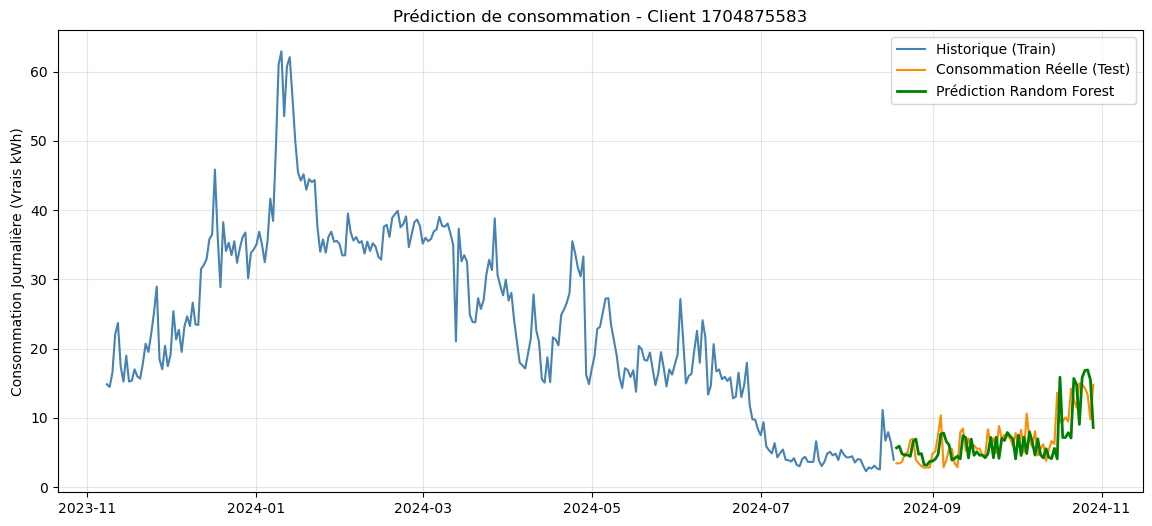


--- MÉTRIQUES D'ÉVALUATION DU FORECASTING ---
Consommation moyenne réelle du client : 7.01 kWh/jour
MAE (Erreur Moyenne Absolue) : 2.27 kWh/jour
RMSE (Pénalise les grosses erreurs) : 2.95 kWh/jour
=> En moyenne, le modèle se trompe de 32.4% par rapport à la conso habituelle.


In [38]:
# 1. On prend un client (tu pourras changer ce numéro dans ton dashboard Streamlit)
client_test_id = daily['pdl_id'].unique()[0]
df_client = daily[daily['pdl_id'] == client_test_id][['date', 'daily_kwh', 'dow', 'is_weekend']].copy()

# --- LA CORRECTION D'UNITÉ EST ICI ---
# On divise par 1000 pour passer de Wh à de vrais kWh
df_client['daily_kwh'] = df_client['daily_kwh'] / 1000
# -------------------------------------

df_client['date'] = pd.to_datetime(df_client['date'])
df_client.set_index('date', inplace=True)
df_client = df_client.sort_index()

# 2. Création des indices (Lags)
df_client['conso_hier'] = df_client['daily_kwh'].shift(1)
df_client['conso_semaine_derniere'] = df_client['daily_kwh'].shift(7)

# On supprime les jours sans historique
df_client = df_client.dropna() 

# 3. Définir X et y
X_fore = df_client[['conso_hier', 'conso_semaine_derniere', 'dow', 'is_weekend']]
y_fore = df_client['daily_kwh']

# 4. Séparation Train / Test chronologique
train_size = int(len(df_client) * 0.8)
X_train_f, X_test_f = X_fore.iloc[:train_size], X_fore.iloc[train_size:]
y_train_f, y_test_f = y_fore.iloc[:train_size], y_fore.iloc[train_size:]

# 5. Entraînement du modèle Regressor
modele_rf_fore = RandomForestRegressor(n_estimators=100, random_state=42)
modele_rf_fore.fit(X_train_f, y_train_f)

# 6. Prédiction du futur
predictions_rf = modele_rf_fore.predict(X_test_f)

# 7. Affichage Graphique
plt.figure(figsize=(14, 6))
plt.plot(y_train_f.index, y_train_f, label='Historique (Train)', color='steelblue')
plt.plot(y_test_f.index, y_test_f, label='Consommation Réelle (Test)', color='darkorange')
plt.plot(y_test_f.index, predictions_rf, color='green', label='Prédiction Random Forest', linewidth=2)
plt.title(f"Prédiction de consommation - Client {client_test_id}")
plt.ylabel("Consommation Journalière (Vrais kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Calcul des métriques d'erreur
mae = mean_absolute_error(y_test_f, predictions_rf)
rmse = np.sqrt(mean_squared_error(y_test_f, predictions_rf))
moyenne_client = y_test_f.mean()

print("\n--- MÉTRIQUES D'ÉVALUATION DU FORECASTING ---")
print(f"Consommation moyenne réelle du client : {moyenne_client:.2f} kWh/jour")
print(f"MAE (Erreur Moyenne Absolue) : {mae:.2f} kWh/jour")
print(f"RMSE (Pénalise les grosses erreurs) : {rmse:.2f} kWh/jour")

erreur_pourcentage = (mae / moyenne_client) * 100
print(f"=> En moyenne, le modèle se trompe de {erreur_pourcentage:.1f}% par rapport à la conso habituelle.")

prédictions sur le même client avec ARIMA

Entraînement ARIMA sur 285 jours, Prédiction sur 72 jours.


c:\Users\Sarah\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\Sarah\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\Sarah\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



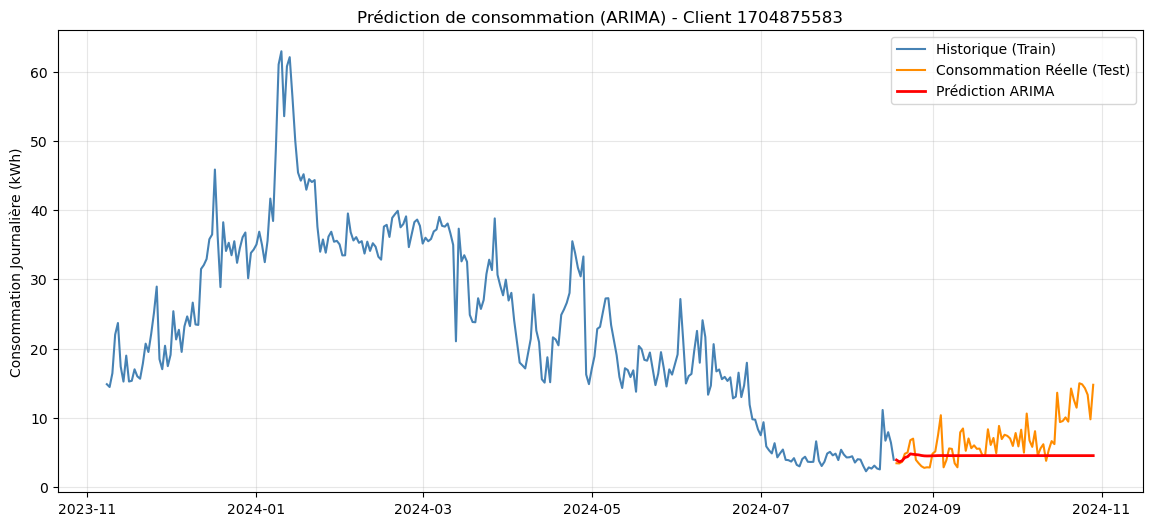


--- MÉTRIQUES D'ÉVALUATION (ARIMA) ---
MAE (Erreur Moyenne) : 2.92 kWh/jour
RMSE (Grosses erreurs) : 4.07 kWh/jour


In [39]:
# 1. On prépare les données (On utilise le même df_client que dans ton code Random Forest)
# ARIMA n'a pas besoin de 'is_weekend' ou 'conso_hier', il n'a besoin QUE de la courbe historique
df_arima = df_client[['daily_kwh']].copy()

# 2. Séparation Train / Test (Toujours chronologique, 80/20)
train_size = int(len(df_arima) * 0.8)
train_arima = df_arima.iloc[:train_size]
test_arima = df_arima.iloc[train_size:]

print(f"Entraînement ARIMA sur {len(train_arima)} jours, Prédiction sur {len(test_arima)} jours.")

# 3. Création et entraînement du modèle ARIMA
# order=(7, 1, 1) veut dire : regarde 7 jours en arrière (pour la semaine), 
# applique 1 niveau de différence (pour la tendance), et lisse l'erreur (1).
modele_arima = ARIMA(train_arima['daily_kwh'], order=(7, 1, 1))
resultats_arima = modele_arima.fit()

# 4. Prédiction du futur (sur la période du Test)
predictions_arima = resultats_arima.forecast(steps=len(test_arima))
predictions_arima.index = test_arima.index # On aligne les dates pour le graphique

# 5. Affichage Comparatif
plt.figure(figsize=(14, 6))
plt.plot(train_arima.index, train_arima['daily_kwh'], label='Historique (Train)', color='steelblue')
plt.plot(test_arima.index, test_arima['daily_kwh'], label='Consommation Réelle (Test)', color='darkorange')
plt.plot(test_arima.index, predictions_arima, color='red', label='Prédiction ARIMA', linewidth=2)
plt.title(f"Prédiction de consommation (ARIMA) - Client {client_test_id}")
plt.ylabel("Consommation Journalière (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Métriques pour le match ARIMA vs Random Forest
mae_arima = mean_absolute_error(test_arima['daily_kwh'], predictions_arima)
rmse_arima = np.sqrt(mean_squared_error(test_arima['daily_kwh'], predictions_arima))

print("\n--- MÉTRIQUES D'ÉVALUATION (ARIMA) ---")
print(f"MAE (Erreur Moyenne) : {mae_arima:.2f} kWh/jour")
print(f"RMSE (Grosses erreurs) : {rmse_arima:.2f} kWh/jour")

prédictions sur un client choisi aléatoirement

--- Lancement de la prédiction pour le client mystère n° 382987677293 ---


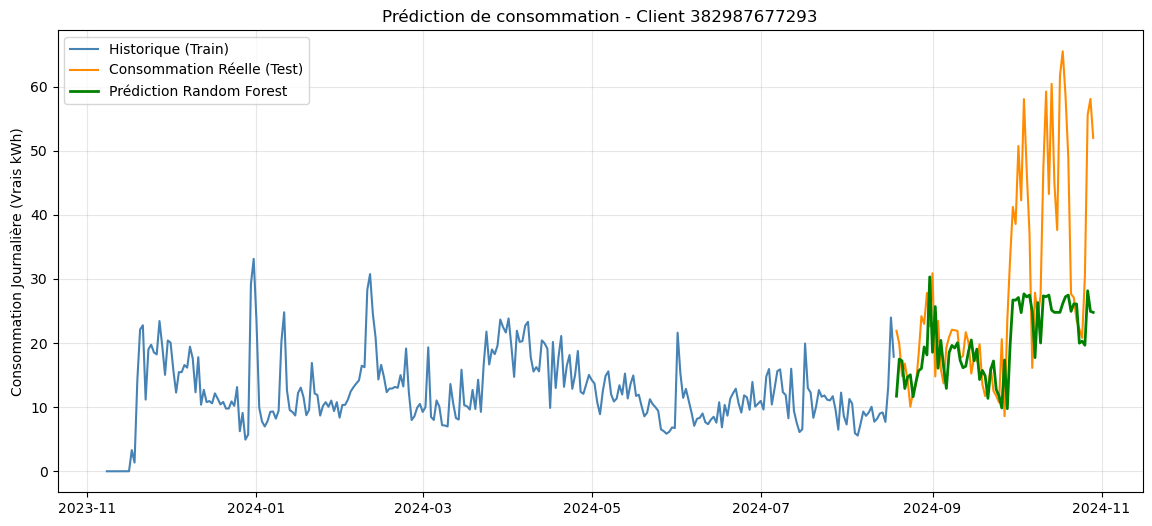


--- MÉTRIQUES D'ÉVALUATION DU FORECASTING ---
Consommation moyenne réelle du client : 28.09 kWh/jour
MAE (Erreur Moyenne Absolue) : 10.03 kWh/jour
RMSE (Pénalise les grosses erreurs) : 14.40 kWh/jour
=> En moyenne, le modèle se trompe de 35.7% par rapport à la conso habituelle.


In [40]:
# 1. On prend un client AU HASARD à chaque fois qu'on lance la cellule
liste_tous_les_clients = daily['pdl_id'].unique()
client_test_id = np.random.choice(liste_tous_les_clients)

print(f"--- Lancement de la prédiction pour le client mystère n° {client_test_id} ---")

df_client = daily[daily['pdl_id'] == client_test_id][['date', 'daily_kwh', 'dow', 'is_weekend']].copy()

# --- CORRECTION D'UNITÉ ---
# On divise par 1000 pour passer de Wh à de vrais kWh
df_client['daily_kwh'] = df_client['daily_kwh'] / 1000
# -------------------------------------

df_client['date'] = pd.to_datetime(df_client['date'])
df_client.set_index('date', inplace=True)
df_client = df_client.sort_index()

# 2. Création des indices (Lags)
df_client['conso_hier'] = df_client['daily_kwh'].shift(1)
df_client['conso_semaine_derniere'] = df_client['daily_kwh'].shift(7)

# On supprime les jours sans historique
df_client = df_client.dropna() 

# 3. Définir X et y
X_fore = df_client[['conso_hier', 'conso_semaine_derniere', 'dow', 'is_weekend']]
y_fore = df_client['daily_kwh']

# 4. Séparation Train / Test chronologique
train_size = int(len(df_client) * 0.8)
X_train_f, X_test_f = X_fore.iloc[:train_size], X_fore.iloc[train_size:]
y_train_f, y_test_f = y_fore.iloc[:train_size], y_fore.iloc[train_size:]

# 5. Entraînement du modèle Regressor
modele_rf_fore = RandomForestRegressor(n_estimators=100, random_state=42)
modele_rf_fore.fit(X_train_f, y_train_f)

# 6. Prédiction du futur
predictions_rf = modele_rf_fore.predict(X_test_f)

# 7. Affichage Graphique
plt.figure(figsize=(14, 6))
plt.plot(y_train_f.index, y_train_f, label='Historique (Train)', color='steelblue')
plt.plot(y_test_f.index, y_test_f, label='Consommation Réelle (Test)', color='darkorange')
plt.plot(y_test_f.index, predictions_rf, color='green', label='Prédiction Random Forest', linewidth=2)
plt.title(f"Prédiction de consommation - Client {client_test_id}")
plt.ylabel("Consommation Journalière (Vrais kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Calcul des métriques d'erreur
mae = mean_absolute_error(y_test_f, predictions_rf)
rmse = np.sqrt(mean_squared_error(y_test_f, predictions_rf))
moyenne_client = y_test_f.mean()

print("\n--- MÉTRIQUES D'ÉVALUATION DU FORECASTING ---")
print(f"Consommation moyenne réelle du client : {moyenne_client:.2f} kWh/jour")
print(f"MAE (Erreur Moyenne Absolue) : {mae:.2f} kWh/jour")
print(f"RMSE (Pénalise les grosses erreurs) : {rmse:.2f} kWh/jour")

# On évite de diviser par zéro si le client a une conso moyenne de 0
if moyenne_client > 0:
    erreur_pourcentage = (mae / moyenne_client) * 100
    print(f"=> En moyenne, le modèle se trompe de {erreur_pourcentage:.1f}% par rapport à la conso habituelle.")
else:
    print("=> Ce client ne consomme rien (Logement vide ou compteur coupé).")

## 9. Génération de courbes de consommation

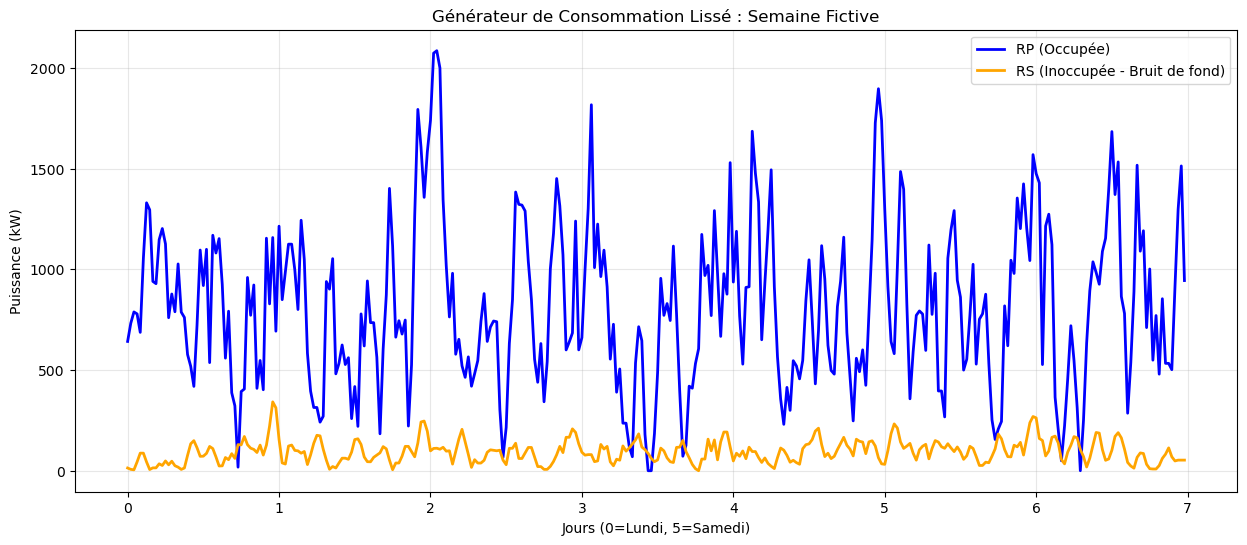

In [41]:
# 1. On prépare les données : on raccroche les labels (0=RP, 1=RS) à la grosse table de base (df)
# (Celle qui contient les consos toutes les 30 minutes)
df_gen = df.merge(output_df[['id', 'label']], left_on='pdl_id', right_on='id', how='inner')

# On s'assure d'avoir la colonne 'is_weekend'
df_gen["is_weekend"] = df_gen["datetime"].dt.dayofweek >= 5

# 2. On calcule le "Profil Type"
# Pour chaque label (RP/RS), chaque type de jour (Semaine/Weekend), et chaque demi-heure (0 à 47),
# on calcule la moyenne et la variation (écart-type / std).
profil_stats = df_gen.groupby(['label', 'is_weekend', 'hh_index'])['p_kw'].agg(['mean', 'std']).reset_index()

# 3. La Fonction Génératrice
def generer_courbe(type_client, nb_jours=7):
    """ Génère une courbe fictive de consommation par pas de 30 min. """
    courbe_generee = []
    
    for jour in range(nb_jours):
        # Si on commence un Lundi (jour 0), les jours 5 et 6 sont le week-end
        est_weekend = (jour % 7 >= 5) 
        
        # On filtre nos statistiques pour ce profil exact
        stats_jour = profil_stats[(profil_stats['label'] == type_client) & 
                                  (profil_stats['is_weekend'] == est_weekend)].sort_values('hh_index')
        
        # Pour chaque demi-heure du jour (48 pas)
        for _, row in stats_jour.iterrows():
            # On tire une valeur au hasard suivant une Loi Normale (Gaussienne)
            valeur_simulee = np.random.normal(loc=row['mean'], scale=row['std'])
            
            # Une consommation électrique ne peut pas être négative, on bloque à 0 au minimum
            valeur_simulee = max(0, valeur_simulee)
            
            courbe_generee.append(valeur_simulee)
            
    return courbe_generee

# 4. Action ! Générons 1 semaine
semaine_fictive_rp = generer_courbe(type_client=0, nb_jours=7)
semaine_fictive_rs_brute = generer_courbe(type_client=1, nb_jours=7)

# --- LES AMÉLIORATIONS SONT ICI ---
# A. Lissage pour enlever le "brouhaha" (Moyenne mobile sur 3 pas de temps = 1h30 d'inertie)
semaine_rp_lisse = pd.Series(semaine_fictive_rp).rolling(window=3, min_periods=1).mean()
semaine_rs_lisse = pd.Series(semaine_fictive_rs_brute).rolling(window=3, min_periods=1).mean()

# B. Simulation physique : On simule une RS "Vide/Inoccupée" (bruit de fond uniquement)
# Car en réalité, une RS n'est pas "moyennement" occupée, elle est soit vide (80% du temps), soit pleine.
semaine_rs_vide = semaine_rs_lisse * 0.15 # On réduit à 15% pour simuler la veille (frigo, box)
# -----------------------------------

# 5. Affichage
plt.figure(figsize=(15, 6))
jours_x = np.arange(len(semaine_rp_lisse)) / 48 

plt.plot(jours_x, semaine_rp_lisse, label='RP (Occupée)', color='blue', linewidth=2)
plt.plot(jours_x, semaine_rs_vide, label='RS (Inoccupée - Bruit de fond)', color='orange', linewidth=2)

plt.title("Générateur de Consommation Lissé : Semaine Fictive")
plt.xlabel("Jours (0=Lundi, 5=Samedi)")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Forecasting avec Régression Linéaire 

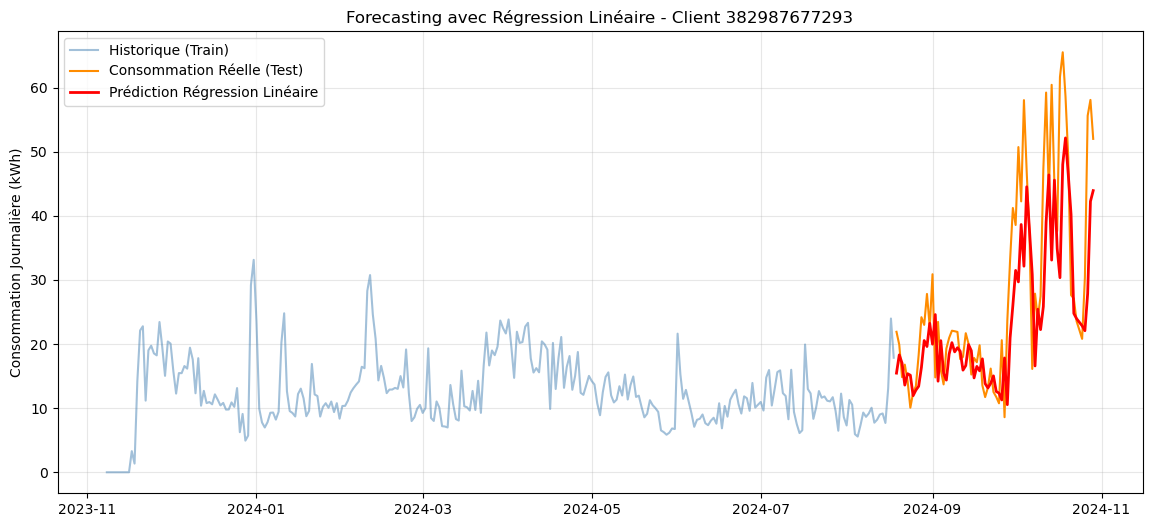


--- MÉTRIQUES D'ÉVALUATION (RÉGRESSION LINÉAIRE) ---
MAE (Erreur Moyenne) : 6.86 kWh/jour
RMSE : 10.07 kWh/jour
=> Le modèle Linéaire se trompe de 24.4%


In [50]:
from sklearn.linear_model import LinearRegression

# 1. Préparation (On utilise les mêmes X et y que pour le Random Forest)
# Assure-toi que X_train_f, X_test_f, y_train_f et y_test_f sont bien définis
# (ceux créés dans ta cellule précédente)

# 2. Entraînement du modèle LinearRegression
modele_lr_fore = LinearRegression()
modele_lr_fore.fit(X_train_f, y_train_f)

# 3. Prédiction du futur
predictions_lr = modele_lr_fore.predict(X_test_f)

# 4. Affichage Graphique Comparatif
plt.figure(figsize=(14, 6))
plt.plot(y_train_f.index, y_train_f, label='Historique (Train)', color='steelblue', alpha=0.5)
plt.plot(y_test_f.index, y_test_f, label='Consommation Réelle (Test)', color='darkorange')
plt.plot(y_test_f.index, predictions_lr, color='red', label='Prédiction Régression Linéaire', linewidth=2)

plt.title(f"Forecasting avec Régression Linéaire - Client {client_test_id}")
plt.ylabel("Consommation Journalière (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Calcul des métriques d'erreur
mae_lr = mean_absolute_error(y_test_f, predictions_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_f, predictions_lr))
moyenne_client = y_test_f.mean()

print("\n--- MÉTRIQUES D'ÉVALUATION (RÉGRESSION LINÉAIRE) ---")
print(f"MAE (Erreur Moyenne) : {mae_lr:.2f} kWh/jour")
print(f"RMSE : {rmse_lr:.2f} kWh/jour")

erreur_pct_lr = (mae_lr / moyenne_client) * 100
print(f"=> Le modèle Linéaire se trompe de {erreur_pct_lr:.1f}%")